In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = pd.read_csv(r"C:\Users\USER\proppulse-california-housing\housing.csv")

# Basic info about dataset
print(data.info())  # Columns, data types, missing values check
print(data.describe())  # Summary stats
print(data.head())  # First few rows


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952

In [39]:
# Check missing values
print(data.isnull().sum())

# Selecting columns with <3% missing values for imputation
cols = [var for var in data.columns if 0 < data[var].isnull().mean() < 0.03]
print("Columns with <3% missing values:", cols)

# Fill missing values with median
data['total_bedrooms'] = data['total_bedrooms'].fillna(data['total_bedrooms'].median())

# Verify missing values handled
print(data.isnull().sum())


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64
Columns with <3% missing values: ['total_bedrooms']
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


In [40]:
def count_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((data[column] < lower_bound) | (data[column] > upper_bound)).sum()
    total = len(data[column])
    percentage = (outliers / total) * 100
    return outliers, percentage

for col in data.select_dtypes(include=['number']).columns:
    count, percent = count_outliers_iqr(data, col)
    print(f"{col}: {count} outliers ({percent:.2f}%)")


longitude: 0 outliers (0.00%)
latitude: 0 outliers (0.00%)
housing_median_age: 0 outliers (0.00%)
total_rooms: 1287 outliers (6.24%)
total_bedrooms: 1306 outliers (6.33%)
population: 1196 outliers (5.79%)
households: 1220 outliers (5.91%)
median_income: 681 outliers (3.30%)
median_house_value: 1071 outliers (5.19%)


In [41]:
# # Encoding categorical variable 'ocean_proximity'
# print("Categorical columns:", data.select_dtypes(include=['object']).columns)

# # Convert categorical column to dummy variables
# data = pd.get_dummies(data, columns=['ocean_proximity'], drop_first=True)

# # Creating new feature ratios
# data['bedroom_ratio'] = data['total_bedrooms'] / data['total_rooms']
# data['household_rooms'] = data['total_rooms'] / data['households']


# # Log transformation for skewed numerical features
# for col in ['total_rooms', 'total_bedrooms', 'population', 'households']:
#     data[col] = np.log1p(data[col])


# # Checking final feature set
# print(data.head())
import numpy as np
import pandas as pd

# Encoding categorical variable 'ocean_proximity'
print("Categorical columns:", data.select_dtypes(include=['object']).columns)

# Convert categorical column to dummy variables
data = pd.get_dummies(data, columns=['ocean_proximity'], drop_first=True)

# Creating new feature ratios
data['bedroom_ratio'] = data['total_bedrooms'] / data['total_rooms']
data['household_rooms'] = data['total_rooms'] / data['households']

# Log transformation for skewed numerical features
for col in ['total_rooms', 'total_bedrooms', 'population', 'households']:
    data[col] = np.log1p(data[col])

# ✅ Function to Count Outliers After Transformation
def count_outliers(df):
    outlier_info = {}
    
    for col in df.select_dtypes(include=[np.number]):  # Only for numeric columns
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
        outlier_percentage = (outliers / len(df)) * 100
        outlier_info[col] = f"{outliers} outliers ({outlier_percentage:.2f}%)"
    
    return outlier_info

# 📢 Get Outliers After Transformation
outlier_counts = count_outliers(data)

# Print the results
for feature, count in outlier_counts.items():
    print(f"{feature}: {count}")


Categorical columns: Index(['ocean_proximity'], dtype='object')
longitude: 0 outliers (0.00%)
latitude: 0 outliers (0.00%)
housing_median_age: 0 outliers (0.00%)
total_rooms: 957 outliers (4.64%)
total_bedrooms: 836 outliers (4.05%)
population: 848 outliers (4.11%)
households: 882 outliers (4.27%)
median_income: 681 outliers (3.30%)
median_house_value: 1071 outliers (5.19%)
bedroom_ratio: 635 outliers (3.08%)
household_rooms: 511 outliers (2.48%)


In [42]:
from sklearn.model_selection import train_test_split

# Define features (X) and target variable (y)
X = data.drop(['median_house_value'], axis=1)
y = data['median_house_value']

# Split data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Combine X_train & y_train for further preprocessing
train_data = X_train.join(y_train)

# Check shape of train and test data
print("Train Data Shape:", train_data.shape)
print("Test Data Shape:", X_test.shape)


Train Data Shape: (16512, 15)
Test Data Shape: (4128, 14)


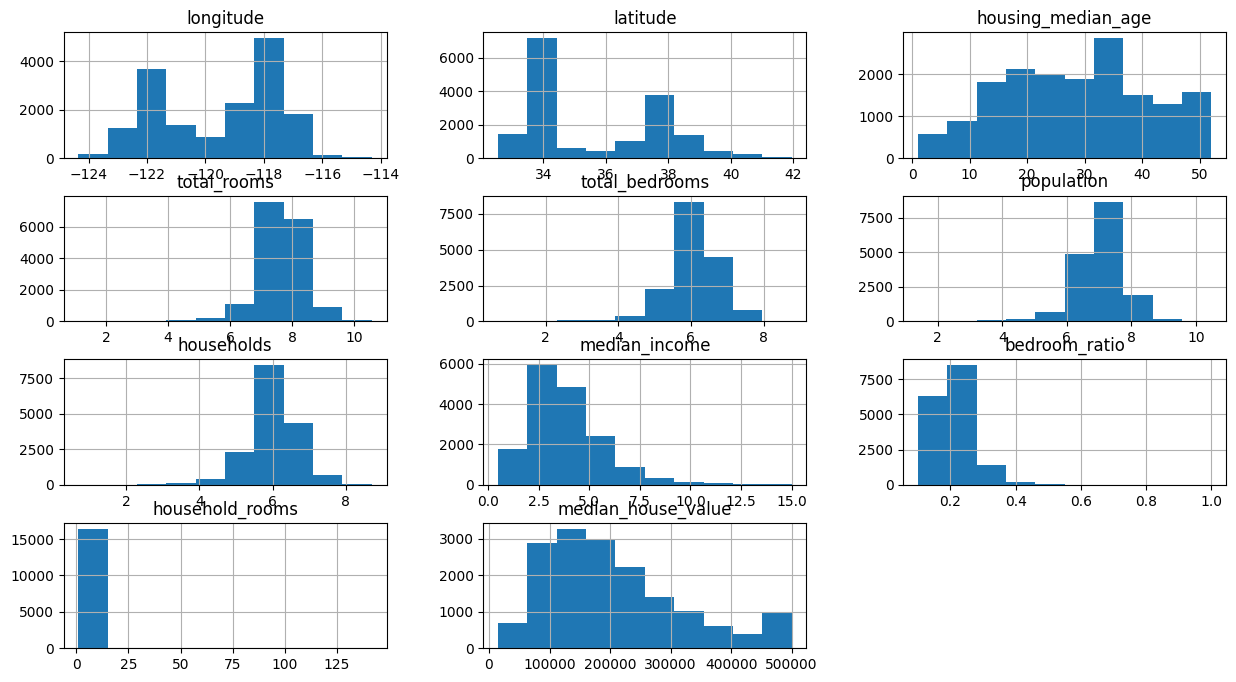

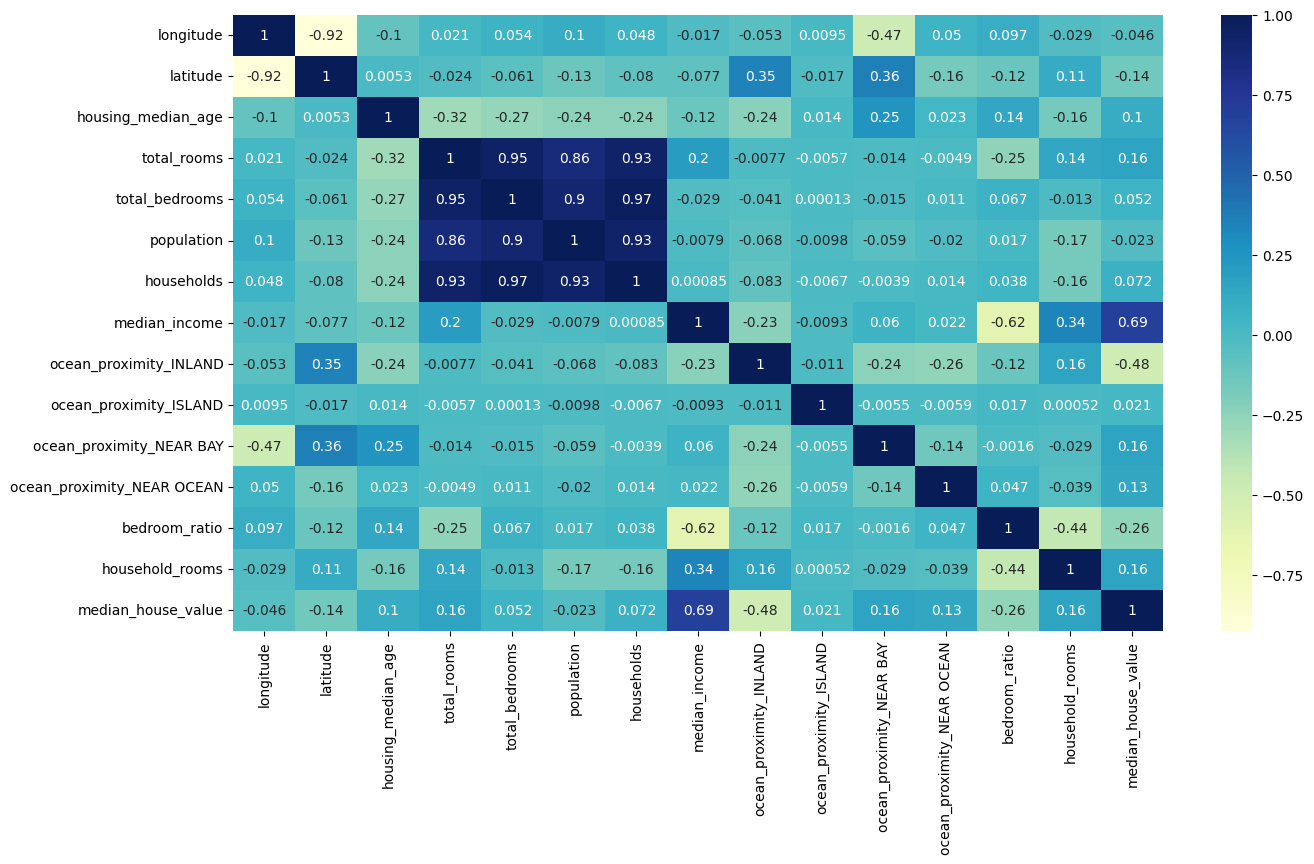

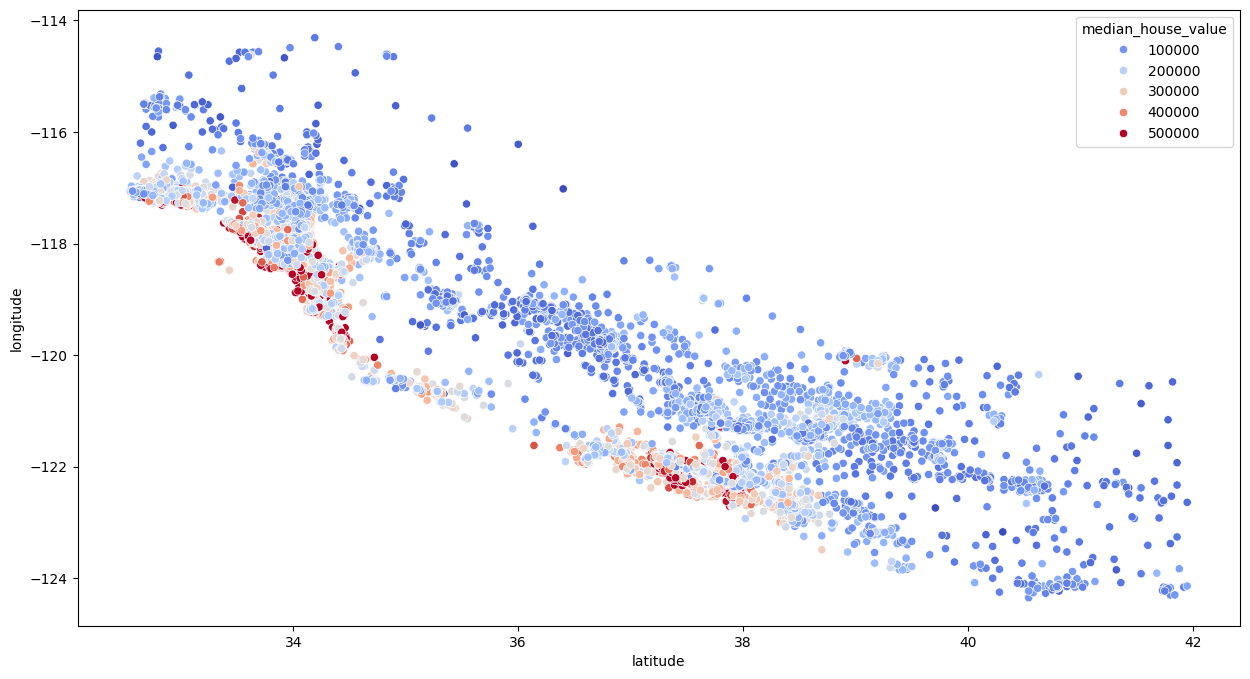

In [43]:
# Histogram of training data features
train_data.hist(figsize=(15, 8))
plt.show()

# Correlation heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(train_data.corr(), annot=True, cmap="YlGnBu")
plt.show()

# Scatter plot to analyze location impact on house prices
plt.figure(figsize=(15, 8))
sns.scatterplot(x="latitude", y="longitude", data=train_data, hue="median_house_value", palette="coolwarm")
plt.show()



In [44]:
from sklearn.linear_model import LinearRegression

# Splitting training data into features (X_train) and target variable (y_train)
X_train = train_data.drop(['median_house_value'], axis=1)
y_train = train_data['median_house_value']

# Initialize and train the Linear Regression model
reg = LinearRegression()
reg.fit(X_train, y_train)

# Print model coefficients
print("Model Coefficients:", reg.coef_)
print("Intercept:", reg.intercept_)


Model Coefficients: [-29680.52721863 -28778.6323406    1083.29236916  33564.83760774
   3021.09073285 -90946.67943145  61355.51195279  41099.75281689
 -33294.45629035 113616.65118986  -8530.57478773  -1941.93364223
 347506.35444642   1163.75334953]
Intercept: -2578094.333621825


In [45]:
from sklearn.tree import DecisionTreeRegressor

# Initialize Decision Tree model
dt_reg = DecisionTreeRegressor(random_state=42)

# Train model on training data
dt_reg.fit(X_train, y_train)

# Print model details
print("Decision Tree Model Trained Successfully!")


Decision Tree Model Trained Successfully!


In [46]:
# Predict using Linear Regression
y_pred_lr = reg.predict(X_test)

# Predict using Decision Tree Regressor
y_pred_dt = dt_reg.predict(X_test)

# Display first 5 predictions from both models
print("Linear Regression Predictions:", y_pred_lr[:5])
print("Decision Tree Predictions:", y_pred_dt[:5])


Linear Regression Predictions: [ 51357.72687095 125094.71980936 267101.20281772 261656.62235456
 262606.32254232]
Decision Tree Predictions: [ 47600. 118800. 500000. 225800. 319800.]


In [47]:
from sklearn.metrics import mean_squared_error, r2_score

# R² Score (Coefficient of Determination)
r2_lr = r2_score(y_test, y_pred_lr)
r2_dt = r2_score(y_test, y_pred_dt)

# Root Mean Squared Error (RMSE) - Manually taking square root
rmse_lr = mean_squared_error(y_test, y_pred_lr) ** 0.5
rmse_dt = mean_squared_error(y_test, y_pred_dt) ** 0.5

print(f"Linear Regression -> R² Score: {r2_lr:.4f}, RMSE: {rmse_lr:.2f}")
print(f"Decision Tree -> R² Score: {r2_dt:.4f}, RMSE: {rmse_dt:.2f}")


Linear Regression -> R² Score: 0.6035, RMSE: 72081.36
Decision Tree -> R² Score: 0.5988, RMSE: 72509.43


In [48]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest Regressor ka model initialize karna
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)

# Model ko training data par fit karna
rf_reg.fit(X_train, y_train)

# Test data par predictions karna
y_pred_rf = rf_reg.predict(X_test)

from sklearn.metrics import r2_score, mean_squared_error

# R² Score
r2_rf = r2_score(y_test, y_pred_rf)

# Root Mean Squared Error (RMSE)
# rmse_rf = mean_squared_error(y_test, y_pred_rf, squared=False)

rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5

print(f"Random Forest -> R² Score: {r2_rf:.4f}, RMSE: {rmse_rf:.2f}")


Random Forest -> R² Score: 0.8085, RMSE: 50097.49


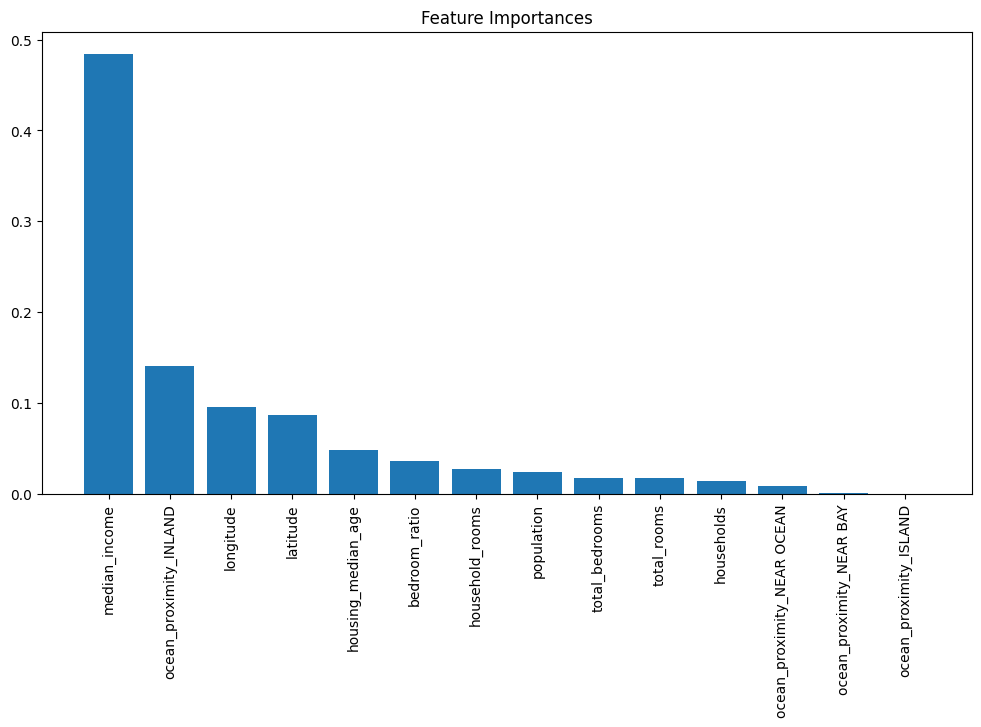

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# Feature importances ko nikalna
importances = rf_reg.feature_importances_

# Features ke naam
features = X_train.columns

# Importances ko sort karna
indices = np.argsort(importances)[::-1]

# Plot karna
plt.figure(figsize=(12, 6))
plt.title("Feature Importances")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), [features[i] for i in indices], rotation=90)
plt.show()


Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity_INLAND', 'ocean_proximity_ISLAND',
       'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN',
       'bedroom_ratio', 'household_rooms'],
      dtype='object')
[9.58181998e-02 8.61805185e-02 4.83068146e-02 1.69812227e-02
 1.69947026e-02 2.37218332e-02 1.33858809e-02 4.84590967e-01
 1.40906907e-01 1.33554437e-04 9.94664919e-04 8.58999730e-03
 3.58808839e-02 2.75138533e-02]
